# 🏠 회귀 — 자동 주택 가치 평가(AVM)와 "무엇이 가격을 움직이는가"

`model.fit()` 한 줄로 끝나는 예제는 많습니다. 이 노트북은 그 한 줄 앞뒤에서 실제 프로젝트가 어떻게 굴러가는지를 따라갑니다. 데이터를 의심하는 일부터, 모델을 신뢰할 수 있는지 검증하고, 결과를 사업팀에 설명하기까지요.

처음 보는 통계 용어가 나올 때마다 **📖 개념** 상자로 짧게 설명을 붙였습니다. 이미 아는 내용이면 건너뛰어도 됩니다.

### 🎯 우리가 맡은 일

여러분은 부동산 플랫폼의 데이터 분석가입니다. 두 가지 요청이 동시에 들어왔습니다.

1. **자동 가치 평가(AVM, Automated Valuation Model)**: 매물이 등록되면 적정 시세를 자동으로 추정한다.
2. **가격 설명**: 사업팀이 묻는다. *"무엇이 집값을 올리나요? 소득인가요, 위치인가요? 방을 늘리면 값이 오르나요?"*

1번은 **예측(prediction)**, 2번은 **설명(explanation)** 입니다. 정확히 맞히는 일과 왜 그렇게 나왔는지 밝히는 일은 서로 다른 작업이고, 필요한 도구도 다릅니다. 이 노트북은 둘 다 다룹니다.

### 다룰 내용

| 단계 | 핵심 질문 |
|---|---|
| Part 0~1 | 데이터를 믿어도 되나? 가장 단순한 모델은 얼마나 하나? |
| Part 2 | 성능을 정직하게 재는 법(데이터 누수 막기) |
| Part 3~4 | 점수를 올리는 피처·타깃 변환, 정규화로 모델 고르기 |
| Part 4.5 | 가중치를 직접 조절하기(관측치 가중·계수 제약) |
| Part 5~6 | 무엇이 가격을 움직이나? 계수의 함정과 변수 영향력 분석 |
| Part 7 | 회귀 family 안에서 비선형(스플라인)으로 성능 올리고 해석 도구 재적용 |
| Part 8~9 | 예측에 신뢰구간 붙이기, 어디서 틀리는지 분석 |

데이터는 `sklearn` 에 들어 있는 California Housing(1990년 캘리포니아 인구조사, 구역 단위)을 씁니다. 컬럼이 단순해 기법에 집중하기 좋고, 동시에 실데이터다운 함정(타깃 상한 클리핑)도 들어 있어 정직한 연습이 됩니다.


---
## Part 0. 환경 설정과 데이터 — 모델보다 먼저 데이터를 의심한다

실무에서 가장 흔한 사고는 모델이 아니라 **데이터를 그대로 믿는 것**에서 납니다. 먼저 환경을 맞추고, 데이터를 *정직하게* 들여다봅니다.


In [1]:
# 필요 시 한 번만 설치 (Colab) — shap 은 뒷부분 SHAP 섹션에서만 씁니다
# !pip install -q shap

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ── 한글 폰트 (Colab/Mac/Windows 공용, 런타임 재시작 불필요) ──
def set_korean_font():
    import os, urllib.request
    # 한글 폰트가 마이너스(−)·일부 기호 글리프를 빼먹어 □(두부)로 깨지는 일을 막기 위해
    # "한글폰트 → DejaVu Sans" fallback 체인을 둔다 (matplotlib 3.6+ 글리프 단위 대체)
    plt.rcParams["axes.unicode_minus"] = False
    for name in ["AppleGothic", "Malgun Gothic", "NanumGothic"]:
        if any(name in f.name for f in fm.fontManager.ttflist):
            plt.rcParams["font.family"] = [name, "DejaVu Sans"]
            return name
    path = "/tmp/NanumGothic.ttf"
    if not os.path.exists(path):
        try:
            urllib.request.urlretrieve(
                "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf", path)
        except Exception:
            return None
    fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = ["NanumGothic", "DejaVu Sans"]
    return "NanumGothic"

print("한글 폰트:", set_korean_font())
np.random.seed(42)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110
print("준비 완료 ✓")

한글 폰트: Malgun Gothic
준비 완료 ✓


In [2]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame.copy()

# 컬럼 의미 (실무에선 데이터 사전이 가장 먼저)
설명 = {
    "MedInc":      "구역 가구 중위소득 (만 달러 단위)",
    "HouseAge":    "주택 연식 중앙값 (년)",
    "AveRooms":    "가구당 평균 방 수",
    "AveBedrms":   "가구당 평균 침실 수",
    "Population":  "구역 인구",
    "AveOccup":    "가구당 평균 거주 인원",
    "Latitude":    "위도",
    "Longitude":   "경도",
    "MedHouseVal": "주택 가치 중앙값 (10만 달러 단위) ← 타깃",
}
pd.DataFrame({"컬럼": 설명.keys(), "의미": 설명.values()})

,컬럼,의미
0,MedInc,구역 가구 중위소득 (만 달러 단위)
1,HouseAge,주택 연식 중앙값 (년)
2,AveRooms,가구당 평균 방 수
3,AveBedrms,가구당 평균 침실 수
4,Population,구역 인구
5,AveOccup,가구당 평균 거주 인원
6,Latitude,위도
7,Longitude,경도
8,MedHouseVal,주택 가치 중앙값 (10만 달러 단위) ← 타깃


In [3]:
print("shape:", df.shape)
df.head()

shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 🔎 타깃을 정직하게 — 숨은 상한선 찾기

모델을 짜기 전에 **타깃의 분포**부터 봅니다. 평균·최댓값만 보지 말고, 값이 *비정상적으로 한 곳에 몰려 있는지* 확인하세요. 실데이터에는 측정·기록의 흔적이 남아 있습니다.


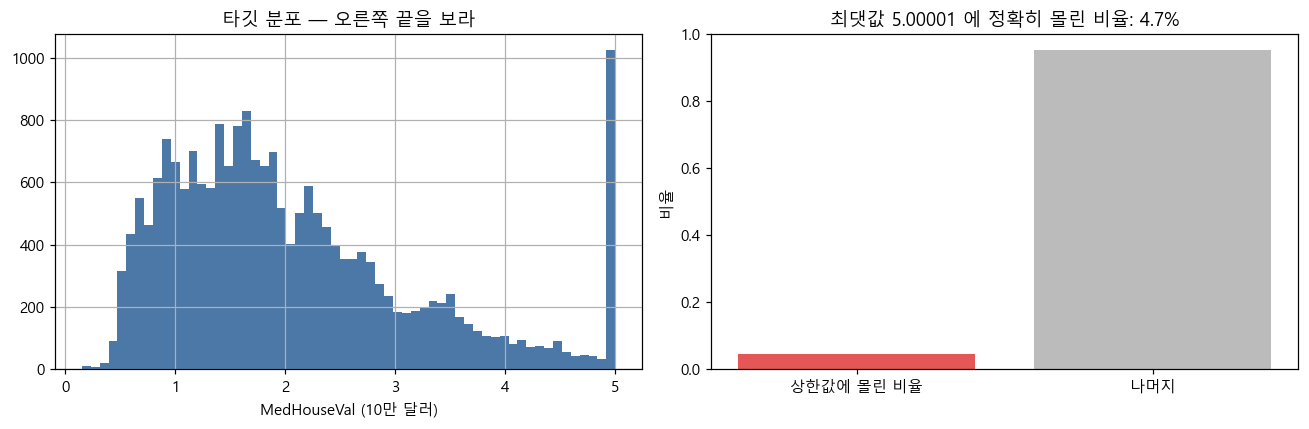

타깃 최댓값 5.00001(=$500k)에 정확히 4.7%가 몰려 있습니다.


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["MedHouseVal"].hist(bins=60, ax=ax[0], color="#4c78a8")
ax[0].set_title("타깃 분포 — 오른쪽 끝을 보라")
ax[0].set_xlabel("MedHouseVal (10만 달러)")

cap = df["MedHouseVal"].max()
capped_ratio = (df["MedHouseVal"] == cap).mean()
ax[1].bar(["상한값에 몰린 비율", "나머지"], [capped_ratio, 1 - capped_ratio],
          color=["#e45756", "#bbbbbb"])
ax[1].set_title(f"최댓값 {cap} 에 정확히 몰린 비율: {capped_ratio:.1%}")
ax[1].set_ylabel("비율")
plt.tight_layout(); plt.show()

print(f"타깃 최댓값 {cap}(=${cap*100:.0f}k)에 정확히 {capped_ratio:.1%}가 몰려 있습니다.")

> ⚠️ **실무 함정 — 상한 클리핑(censoring).** 50만 달러를 넘는 집은 전부 `5.0`(=50만)으로 잘려 기록됐습니다. 약 5%가 이 인공 상한에 붙어 있습니다.
>
> 이걸 모르고 모델을 만들면 **고가 주택을 체계적으로 과소평가**합니다. 실무 대응은 세 갈래입니다.
> 1. 상한 구간을 **별도 분류 문제**로 분리("50만 초과 여부")
> 2. **분위 회귀**로 상한의 영향을 줄이기 (뒤에서 다룸)
> 3. 최소한 **에러 분석에서 이 구간을 따로 떼어** 성능을 보고하기
>
> 지금은 "이 함정이 존재한다"는 사실을 기록해 두고, 마지막 에러 분석에서 다시 만납니다.


---
## Part 1. 베이스라인 — "이걸 못 이기면 모델은 의미가 없다"

복잡한 모델을 만들기 전에, 가장 단순한 예측을 기준선으로 세웁니다. 예를 들어 무조건 평균값만 내미는 모델이 있죠. 이런 모델조차 못 이긴다면 그 모델은 쓸 이유가 없습니다. 실무 보고서의 첫 줄이 거의 항상 "베이스라인 대비 얼마나 개선됐는가"인 이유입니다.


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

TARGET = "MedHouseVal"
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 베이스라인: 무조건 학습셋 평균을 예측
dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

def 평가(y_true, y_pred, 이름):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mape = (np.abs((y_true - y_pred) / y_true)).mean() * 100
    print(f"[{이름:18s}] MAE={mae:.3f} (±${mae*100:.1f}k)  "
          f"RMSE={rmse:.3f}  MAPE={mape:.1f}%")
    return {"이름": 이름, "MAE": mae, "RMSE": rmse, "MAPE": mape}

results = [평가(y_test, pred_dummy, "베이스라인(평균)")]

[베이스라인(평균)         ] MAE=0.906 (±$90.6k)  RMSE=1.145  MAPE=62.9%


### 평가지표를 비즈니스 언어로 고르기

세 지표는 답하는 질문이 다릅니다. 보고서에 **무엇을 쓸지**는 비즈니스가 정합니다.

| 지표 | 식(직관) | 한 줄 의미 | 언제 쓰나 | 함정 |
|---|---|---|---|---|
| **MAE** | 오차 절댓값의 평균 | 평균 절대 오차 (만 달러) | "평균 ±얼마 빗나가나" 직관적 보고 | 큰 오차를 작은 오차와 똑같이 취급 |
| **RMSE** | 오차를 *제곱*해 평균낸 뒤 √ | 큰 오차에 더 큰 벌점 | 고가 매물 한 건의 큰 실수가 치명적일 때 | 이상치에 휘둘림 |
| **MAPE** | (오차 / 실제값)의 절댓값 평균 | 평균 퍼센트 오차 | 가격대가 다른 매물을 공평 비교 | 저가 매물에서 폭증, 0 근처 위험 |

세 지표의 관계를 한 줄로: **RMSE ≥ MAE 가 항상 성립**하고, 둘의 차이가 벌어질수록 "소수의 큰 오차"가 있다는 신호입니다(제곱이 큰 오차를 키우기 때문). 그래서 RMSE와 MAE를 나란히 보면 오차가 고른지 일부에 쏠렸는지 가늠할 수 있습니다.

참고로 이 데이터의 타깃 단위는 10만 달러입니다. 즉 MAE 0.5는 "평균 ±5만 달러 빗나간다"는 뜻입니다.

> 💡 **어떤 지표를 고를까.** AVM 감정가는 보통 MAPE(상대 오차)로 보고합니다. 50만 달러 집의 5만 달러 오차(10%)와 10만 달러 집의 5만 달러 오차(50%)는 의미가 전혀 다르기 때문입니다. 다만 MAPE만 좇으면 저가 매물에 치우치므로 MAE와 함께 봅니다.

---
## Part 2. 성능을 정직하게 재는 법 — 데이터 누수 막기

모델을 처음 배우면 `StandardScaler().fit_transform(X)` 를 전체 데이터에 한 번 돌리고 시작하기 쉬운데, 이것이 **데이터 누수(data leakage)** 입니다. 테스트셋의 평균·분산 정보가 스케일러를 거쳐 학습 단계로 새어 들어가, 실제보다 점수가 좋게 나옵니다. 배포하면 그 차이만큼 성능이 무너집니다.

> 📖 **개념 — 표준화(standardization).** 각 변수에서 그 변수의 평균을 빼고 표준편차로 나눕니다 — 식으로는 `z = (x − 평균) / 표준편차`. 그러면 모든 변수가 "평균 0, 표준편차 1"이라는 같은 잣대로 바뀌고, 값 하나하나는 *"평균에서 몇 표준편차 떨어져 있나"* 를 뜻하게 됩니다. 예컨대 소득 8(만 달러)과 위도 37(도)은 원래 비교할 수 없지만, 표준화하면 둘 다 "+1.5σ"처럼 같은 단위로 읽힙니다.
>
> **왜 필요한가.** ① 선형회귀의 계수는 "변수 1단위 변화당 가격 변화"라서, 단위가 제각각이면(달러 vs 도) 계수 크기로 중요도를 비교할 수 없습니다. ② KNN·SVM은 점 사이의 *거리*로 판단하는데, 범위가 큰 변수가 거리를 독차지해 버립니다. 표준화는 이 둘을 공정하게 만듭니다. 반대로 트리 모델은 "값이 기준보다 큰가/작은가"만 보므로 표준화가 필요 없습니다(Part 7에서 확인).

> 📖 **개념 — 교차검증(cross-validation, CV).** 출발 질문은 *"한 번 나눈 train/test로 잰 점수를 믿어도 되나?"* 입니다. 운 나쁘게 어려운 행들이 test에 몰리면 점수가 나쁘게, 운 좋으면 좋게 나옵니다. 그래서 학습 데이터를 k조각(여기선 5)으로 나눠, **조각을 돌아가며 한 번씩 검증용으로 빼고 나머지 4조각으로 학습**하기를 5번 반복합니다. 모든 행이 정확히 한 번씩 검증에 쓰입니다.
>
> 결과로 점수 5개가 나오고, 우리는 그 **평균**(실력의 추정)과 **표준편차**(분할에 따라 얼마나 흔들리나 = 안정성)를 함께 봅니다. 아래 출력 `5-fold CV MAE: 0.529 ± 0.009` 에서 뒤의 `± 0.009` 가 그 표준편차입니다 — 작을수록 믿을 만한 추정입니다.

> 💡 **핵심 원칙.** 전처리(스케일링·결측 대치·인코딩)는 train 으로만 fit 하고 test 에는 적용(transform)만 합니다. 이 규칙을 교차검증의 매 조각마다 자동으로 지켜 주는 도구가 `Pipeline` 입니다.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

# 스케일러와 모델을 한 묶음으로 — CV 의 매 fold 에서 train 으로만 fit 된다
lin_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
# 회귀 CV 점수는 음수 MAE 로 나온다 (sklearn 관례: 클수록 좋게 부호 반전)
neg_mae = cross_val_score(lin_pipe, X_train, y_train,
                          scoring="neg_mean_absolute_error", cv=cv)
print(f"5-fold CV MAE: {-neg_mae.mean():.3f} ± {neg_mae.std():.3f}")
print("fold별:", np.round(-neg_mae, 3))

5-fold CV MAE: 0.529 ± 0.009
fold별: [0.541 0.529 0.513 0.535 0.528]


In [7]:
# 테스트셋 최종 평가 (CV 로 모델을 고른 뒤, 단 한 번만 본다)
lin_pipe.fit(X_train, y_train)
pred_lin = lin_pipe.predict(X_test)
results.append(평가(y_test, pred_lin, "선형회귀(기본)"))

[선형회귀(기본)          ] MAE=0.533 (±$53.3k)  RMSE=0.746  MAPE=32.0%


> ⚠️ **실무 함정 — 테스트셋을 반복해서 들여다보기.** 테스트셋으로 모델을 고치고 다시 평가하길 반복하면, 결국 테스트셋에 *손으로* 과적합됩니다. 테스트셋은 **모델 선택이 끝난 뒤 마지막에 단 한 번**만 봅니다. 모델 비교·튜닝은 전부 교차검증(train 안)에서 끝내세요.


---
## Part 3. 데이터 정리 + 피처 엔지니어링 — 점수가 실제로 오르는 곳

모델을 바꾸는 것보다 **이상치를 다스리고 변수를 잘 만드는 것**이 점수를 더 크게 올릴 때가 많습니다. 먼저 원시 데이터의 극단값을 확인합니다.


In [8]:
# 기록 오류로 의심되는 극단값 — 가구당 평균 방/인원이 비현실적인 구역
print("원시 데이터 최댓값 (비현실적 극단 확인):")
print(X_train[["AveRooms", "AveBedrms", "AveOccup", "Population"]].max().round(1))
print("\n예: AveOccup 최댓값 = 가구당 평균 거주 인원 — 수백 명은 기록 오류(시설 등)로 봄")

원시 데이터 최댓값 (비현실적 극단 확인):
AveRooms        141.9
AveBedrms        25.6
AveOccup       1243.3
Population    35682.0
dtype: float64

예: AveOccup 최댓값 = 가구당 평균 거주 인원 — 수백 명은 기록 오류(시설 등)로 봄


> ⚠️ **실무 함정 — 이상치를 그대로 비율 피처에 넣기.** `방 수 / 인원` 같은 비율을 만들 때 분모에 극단값이 끼면 피처가 폭발하고, 그 위에 올린 선형 모델은 **음수 집값**을 뱉기도 합니다.
>
> 대응은 **분위수 클리핑(winsorizing)** 입니다. 상·하위 0.5%를 경계값으로 잘라 극단값의 영향을 막습니다. 단, 경계는 train 에서만 구해 test 에 적용해야 누수가 없습니다(스케일러와 같은 원칙입니다).


In [9]:
# train 에서만 0.5% / 99.5% 경계를 구한다 — 테스트 정보 누수 차단
clip_cols = ["AveRooms", "AveBedrms", "AveOccup", "Population"]
lo_caps = X_train[clip_cols].quantile(0.005)
hi_caps = X_train[clip_cols].quantile(0.995)

def add_features(frame):
    f = frame.copy()
    for col in clip_cols:                          # 극단값 방어 (winsorize)
        f[col] = f[col].clip(lo_caps[col], hi_caps[col])
    f["bedroom_ratio"]    = f["AveBedrms"] / f["AveRooms"]      # 방 중 침실 비율
    f["rooms_per_person"] = f["AveRooms"] / f["AveOccup"]       # 1인당 방 수(쾌적도)
    f["pop_per_room"]     = f["Population"] / (f["AveRooms"] * f["AveOccup"]).clip(lower=1)
    return f

X_train_fe = add_features(X_train)
X_test_fe = add_features(X_test)

lin_fe = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
neg_mae_fe = cross_val_score(lin_fe, X_train_fe, y_train,
                             scoring="neg_mean_absolute_error", cv=cv)
print(f"피처 추가 전 CV MAE: {-neg_mae.mean():.3f}")
print(f"피처 추가 후 CV MAE: {-neg_mae_fe.mean():.3f}")

피처 추가 전 CV MAE: 0.529
피처 추가 후 CV MAE: 0.475


### 타깃 변환 — 오른쪽으로 긴 꼬리는 log 로 편다

집값처럼 **오른쪽으로 긴 꼬리(right-skewed)** 를 가진 타깃은, 로그를 씌우면 분포가 대칭에 가까워지고 선형 모델의 가정(등분산·정규 잔차)에 더 잘 맞습니다. 단, **예측값은 다시 지수로 되돌려** 원래 단위로 보고해야 합니다.

> 💡 `TransformedTargetRegressor` 가 이 "변환 → 학습 → 역변환"을 자동으로 처리해 줍니다. 직접 `np.log` 와 `np.exp` 를 쓰다 보면 마지막에 역변환을 깜빡하는 실수가 잦은데, 그걸 막아 줍니다.


In [10]:
from sklearn.compose import TransformedTargetRegressor

lin_log = TransformedTargetRegressor(
    regressor=Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    func=np.log1p, inverse_func=np.expm1,    # log(1+y) ↔ exp(x)-1
)
neg_mae_log = cross_val_score(lin_log, X_train_fe, y_train,
                              scoring="neg_mean_absolute_error", cv=cv)
print(f"피처 추가      CV MAE: {-neg_mae_fe.mean():.3f}")
print(f"피처 + log타깃 CV MAE: {-neg_mae_log.mean():.3f}")

lin_log.fit(X_train_fe, y_train)
pred_loglin = lin_log.predict(X_test_fe)
results.append(평가(y_test, pred_loglin, "선형+FE+log"))

피처 추가      CV MAE: 0.475
피처 + log타깃 CV MAE: 0.475
[선형+FE+log         ] MAE=0.478 (±$47.8k)  RMSE=0.745  MAPE=26.6%


> 💡 **읽는 법 — 왜 점수(MAE)가 그대로인가.** 위 출력에서 CV MAE가 `0.475 → 0.475` 로 사실상 변하지 않습니다. 그렇다고 log 변환이 *아무 일도 안 한* 건 아닙니다. 같은 5-fold CV로 세 지표를 분리해 재보면 (직접 돌려 확인할 수 있습니다):
>
> | 지표 | FE only | FE + log | |
> |---|---|---|---|
> | MAE | 0.475 | 0.475 | 그대로 |
> | RMSE | 0.656 | 0.735 | **나빠짐** |
> | MAPE | 28.5% | 26.1% | **좋아짐** |
>
> 게다가 타깃의 왜도(오른쪽 꼬리의 정도)는 `0.98 → 0.28` 로 크게 펴집니다. 즉 log는 분명히 일을 했는데, **그 효과가 지표마다 정반대**로 나타납니다. log 회귀는 *상대(배수) 오차*를 줄이도록 학습하므로, 저가 매물의 퍼센트 오차가 줄어드는 대신(MAPE↓) 고가 매물의 절대 오차는 커집니다. 그래서 절대 오차를 제곱해 키우는 RMSE는 오히려 나빠지고, 큰 오차에 둔감한 MAE는 이 둘이 상쇄되어 제자리입니다.
>
> **교훈.** 변환은 "좋다/나쁘다"가 아니라 **오차를 어느 쪽으로 재배분하느냐**의 문제입니다. 우리가 추적한 지표가 하필 log가 거의 안 건드리는 MAE였을 뿐 — MAPE로 보고했다면 개선, RMSE로 보고했다면 악화로 보였을 겁니다. **어떤 지표(=어떤 비즈니스 비용)를 고르느냐가 변환의 평가 자체를 바꿉니다**(Part 1에서 지표를 신중히 고른 이유). 이 노트북은 MAE·MAPE를 함께 보고 해석은 원 단위 모델로 따로 가져가므로, 여기서는 log를 굳이 끌고 가지 않습니다.

---
## Part 4. 정규화 회귀 — 다중공선성을 보고 모델을 고른다

> 📖 **개념 — 다중공선성(multicollinearity).** 설명변수끼리 강하게 상관되어 "거의 같은 정보"를 중복으로 담고 있는 상태입니다. 예를 들어 '방 수'와 '침실 수'는 거의 함께 움직이죠. 이러면 모델은 가격 상승분을 방 수 탓으로 볼지 침실 수 탓으로 볼지 갈팡질팡합니다. 둘의 합은 잘 잡아도 *각자에게 얼마씩 배분할지*는 데이터의 작은 흔들림에도 크게 달라져, 계수가 출렁이고 부호까지 뒤집히기도 합니다(예: 방 수 계수가 +0.5였다가 데이터를 조금 바꾸면 −0.3). 신기하게도 합을 잘 잡으니 **예측 성능 자체는 멀쩡할 수 있습니다.** 무너지는 건 "어떤 변수가 얼마나 중요한가"라는 **해석**입니다.

가장 단순한 회귀인 OLS(Ordinary Least Squares, 보통최소제곱)는 이 공선성에 취약합니다. 먼저 VIF로 어느 변수가 중복인지 진단합니다.

> 📖 **개념 — VIF(Variance Inflation Factor, 분산 팽창 계수).** 변수 하나를 *나머지 모든 변수로* 회귀해서, 그 변수가 다른 변수들로 얼마나 잘 설명되는지(R²)를 봅니다. 식은 `VIF = 1 / (1 − R²)`. 다른 변수들로 90% 설명되면(R²=0.9) VIF=10, 95%면 VIF=20으로 치솟습니다. 즉 "이 변수는 사실상 다른 변수들의 재탕"일수록 커집니다. 통상 **1이면 독립, 5를 넘으면 주의, 10 이상이면 공선성이 심하다**고 봅니다. 아래 표에서 `AveRooms` 의 VIF가 24인 건 방·침실·1인당 방수 피처들이 서로 거의 같은 정보를 담고 있다는 신호입니다.

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

Xs = StandardScaler().fit_transform(X_train_fe)
vif = pd.DataFrame({
    "변수": X_train_fe.columns,
    "VIF": [variance_inflation_factor(Xs, i) for i in range(Xs.shape[1])],
}).sort_values("VIF", ascending=False)
print(vif.to_string(index=False))

              변수       VIF
        AveRooms 23.856095
rooms_per_person 15.002672
   bedroom_ratio 10.203631
       AveBedrms  9.876471
        Latitude  9.775077
       Longitude  9.325843
    pop_per_room  7.710224
      Population  6.746351
        AveOccup  6.199638
          MedInc  3.191777
        HouseAge  1.273916


상관 높은 변수쌍(방 관련 변수들, 위·경도 등)이 높은 VIF로 잡힙니다. 이럴 때 **정규화**가 해법입니다.

> 📖 **개념 — 정규화(regularization).** 보통 회귀는 *예측 오차*만 최소화합니다(`최소화: 오차²의 합`). 정규화는 목적함수에 "**계수가 크면 벌점**" 항을 더합니다(`최소화: 오차²의 합 + α × 계수 벌점`). 그러면 모델은 오차를 줄이되 계수를 함부로 키우지 못하고, 공선성 탓에 한 변수엔 큰 양수·다른 변수엔 큰 음수를 몰아주던 출렁임이 가라앉습니다.
>
> 직관적으로는 **"학습 데이터에 덜 휘둘리게(분산↓) 만드는 대신 약간의 치우침(편향↑)을 받아들이는"** 맞바꿈입니다 — 그 대가로 처음 보는 데이터에서 더 안정적이 됩니다. 벌점의 세기가 `alpha`(α)이며, 0이면 일반 회귀와 같고, 키울수록 계수를 0 쪽으로 더 강하게 누릅니다.

벌점을 매기는 방식에 따라 세 가지로 나뉩니다.

- **Ridge (L2)**: 계수의 *제곱합*에 벌점. 계수를 전반적으로 작게 누르되 0으로 만들진 않습니다. 공선성에 강하고 계수가 안정적입니다.
- **Lasso (L1)**: 계수의 *절댓값 합*에 벌점. 덜 중요한 계수를 **정확히 0**으로 만들어, 변수를 자동으로 골라내는 효과가 있습니다.
- **ElasticNet**: L1과 L2를 섞은 것. 상관된 변수 그룹을 함께 다룰 때 유용합니다.

`alpha`는 손으로 정하지 않고 교차검증으로 후보들을 비교해 고릅니다.

In [12]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

alphas = np.logspace(-3, 2, 40)

def make_reg(estimator):
    return TransformedTargetRegressor(
        regressor=Pipeline([("scaler", StandardScaler()), ("model", estimator)]),
        func=np.log1p, inverse_func=np.expm1)

models = {
    "Ridge":      make_reg(RidgeCV(alphas=alphas)),
    "Lasso":      make_reg(LassoCV(alphas=alphas, max_iter=5000, random_state=42)),
    "ElasticNet": make_reg(ElasticNetCV(alphas=alphas, l1_ratio=[.2,.5,.8,1.0],
                                        max_iter=5000, random_state=42)),
}
for name, m in models.items():
    s = cross_val_score(m, X_train_fe, y_train,
                        scoring="neg_mean_absolute_error", cv=cv)
    print(f"{name:11s} CV MAE: {-s.mean():.3f} ± {s.std():.3f}")

Ridge       CV MAE: 0.475 ± 0.010
Lasso       CV MAE: 0.476 ± 0.010
ElasticNet  CV MAE: 0.475 ± 0.010


In [13]:
# 셋 중 가장 단순하면서 점수가 비슷한 Ridge 를 대표 선형 모델로 채택
ridge = models["Ridge"].fit(X_train_fe, y_train)
pred_ridge = ridge.predict(X_test_fe)
results.append(평가(y_test, pred_ridge, "Ridge+FE+log"))

# Lasso 가 0 으로 보낸 변수 확인 (자동 변수 선택)
lasso_fitted = models["Lasso"].fit(X_train_fe, y_train)
lasso_coef = lasso_fitted.regressor_.named_steps["model"].coef_
선택 = pd.Series(lasso_coef, index=X_train_fe.columns)
print("\nLasso 가 0 으로 버린 변수:", list(선택[선택 == 0].index) or "(없음)")

[Ridge+FE+log      ] MAE=0.478 (±$47.8k)  RMSE=0.745  MAPE=26.7%

Lasso 가 0 으로 버린 변수: ['AveRooms', 'Population']


---
## Part 4.5. 다중회귀에서 가중치를 직접 조절하기 — 정규화 너머

Part 4의 정규화(Ridge·Lasso)도 사실 **계수(가중치)를 줄이는** 한 방법이었습니다. 그런데 정규화는 모든 계수를 *일률적으로* 누릅니다. 실무에선 더 구체적인 요구가 자주 생깁니다.

- *"최근 거래를, 또는 믿을 만한 출처의 데이터를 **더 무겁게** 반영하고 싶다"* → **① 관측치 가중(sample weight)**
- *"방 수 계수가 음수로 나오면 곤란하다 — 상식·규제에 맞게 **부호를 고정**하고 싶다"* → **② 계수 제약(constrained regression)**

두 축은 회귀의 **목적함수 자체**를 손보는 방법입니다. 정규화가 "계수를 작게"라면, 이쪽은 "**어떤 데이터를·어떤 방향으로** 더 신뢰할지"를 직접 지정합니다.


### ① 관측치 가중 — 어떤 행을 더 믿을지 (sample_weight)

보통 최소제곱은 **모든 관측치를 동등하게** 취급합니다. `sample_weight` 로 행마다 중요도를 다르게 줄 수 있습니다. 수학적으로는 가중 최소제곱(WLS) — 오차 제곱에 가중치를 곱해 최소화합니다.

**실무 유스케이스**
- **최신성 가중**: 시세가 변하면 최근 거래에 큰 가중 (시간 컬럼이 있을 때)
- **신뢰도 가중**: 출처·측정 신뢰도가 낮은 행을 낮은 가중으로 (예: Part 0의 *상한 클리핑된 5%* 는 참값이 불확실하니 가중을 낮춘다)
- **비용 가중**: *오차의 비즈니스 비용*이 큰 구간을 더 무겁게 (고가 매물 오차가 더 비싸다면 고가에 가중)
- **편향 보정**: 표본이 모집단과 다르면 역확률 가중(IPW)으로 분포를 맞춘다

아래는 *"고가 매물 오차가 더 비싸다"* 는 비즈니스 가정으로, 가격에 비례한 가중을 준 경우입니다.


In [14]:
from sklearn.linear_model import Ridge

# 가중치: 가격에 비례 — 고가 매물 한 건의 오차를 더 무겁게 본다
w = (y_train.values / y_train.values.mean())

base = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))])
ridge_uniform = base.fit(X_train_fe, y_train)                       # 균일 가중(기본)
ridge_weighted = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))])
ridge_weighted.fit(X_train_fe, y_train, model__sample_weight=w)     # 가격 비례 가중

hi = y_test.values >= y_test.quantile(0.8)        # 상위 20% 고가 구역
for 이름, m in [("균일 가중", ridge_uniform), ("고가 가중", ridge_weighted)]:
    p = m.predict(X_test_fe)
    print(f"{이름} — 전체 MAE {mean_absolute_error(y_test, p):.3f} | "
          f"고가20% MAE {mean_absolute_error(y_test[hi], p[hi]):.3f}")

균일 가중 — 전체 MAE 0.480 | 고가20% MAE 0.853
고가 가중 — 전체 MAE 0.537 | 고가20% MAE 0.679


> 💡 **읽는 법.** 가격에 가중을 주면 **고가 구역 MAE가 내려가는 대신 전체 MAE는 약간 올라갑니다** — 모델의 관심을 고가 쪽으로 *재배분*한 결과입니다. 정답이 있는 게 아니라 **무엇을 더 잘 맞히고 싶은가**라는 비즈니스 선택입니다. 파이프라인에 가중치를 넘길 땐 `model__sample_weight=` 처럼 **단계 이름을 접두어**로 붙입니다(누수 없이 스케일링과 함께 동작).


### ② 계수 제약 — 도메인 지식을 모델에 강제하기 (단, 제약이 맞아야 한다)

가장 흔한 계수 제약은 **비음수 제약(NNLS)** 입니다. 모든 계수가 0 이상이 되도록 강제하는 것이죠. 효과 부호가 음수면 곤란한 문제, 예컨대 비용을 구성요소로 분해하는데 각 항목이 비용을 깎을 수는 없는 경우에 씁니다. 그런데 **제약이 도메인과 맞지 않으면 오히려 신호를 죽입니다.** 이 데이터로 직접 확인해 보겠습니다.


In [15]:
# 일반 OLS vs 전역 비음수 제약 — 부호가 어떻게 바뀌나
ols  = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]).fit(X_train_fe, y_train)
nnls = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression(positive=True))]).fit(X_train_fe, y_train)

비교 = pd.DataFrame({
    "OLS 계수": ols.named_steps["model"].coef_,
    "비음수제약 계수": nnls.named_steps["model"].coef_,
}, index=X_train_fe.columns).round(3)
print(비교)
print("\n전역 비음수 제약이 0 으로 만든 변수:",
      list(비교.index[(비교["OLS 계수"] < 0)]))

                  OLS 계수  비음수제약 계수
MedInc             0.757     0.971
HouseAge           0.138     0.252
AveRooms          -0.030     0.000
AveBedrms         -0.145     0.000
Population        -0.003     0.000
AveOccup          -0.026     0.000
Latitude          -0.910     0.000
Longitude         -0.843     0.000
bedroom_ratio      0.281     0.319
rooms_per_person   0.411     0.217
pop_per_room       0.066     0.136

전역 비음수 제약이 0 으로 만든 변수: ['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


> ⚠️ **여기서 배우는 진짜 교훈 — 틀린 제약은 신호를 죽인다.**
> 비음수 제약이 `Latitude`·`Longitude` 계수를 **0 으로 지워버렸습니다.** 그런데 캘리포니아에서 *위도가 높을수록(북쪽)·내륙일수록 값이 싸다*는 **음수 효과는 정상이고 중요한 신호**입니다. 전역 비음수 제약은 이 위치 정보를 통째로 날려 버립니다.
>
> 즉, **비음수 제약은 "모든 효과가 양수"라고 도메인이 보장할 때만** 써야 합니다. `AveRooms` 부호 하나가 문제라면, 전역 제약 대신 (1) 공선 변수를 정리하거나 (2) **그 변수에만 단조 제약**을 거는 게 맞습니다.

**그 외 자주 쓰는 계수 제약**

| 제약 | 도구 | 유스케이스 |
|---|---|---|
| 비음수 (≥0) | `LinearRegression(positive=True)`, `Lasso(positive=True)` | 효과 부호가 음수면 곤란할 때 (가격 구성요소 분해 등) |
| **단조 제약** | 트리 모델 `monotonic_cst`, 단조 스플라인·등위회귀(isotonic) | *"소득↑ ⇒ 예측 가격↑"* 을 규제·상식으로 **보장** (비선형이어도) |
| 사용자 정의 가중·제약 | `cvxpy` 등 볼록 최적화 | 합=1, 상·하한 등 복잡한 비즈니스 제약 |

> 💡 **단조 제약**은 비선형 트리 모델에서 특히 강력합니다. 데이터 노이즈 탓에 *"중간 소득 구간에서 가격이 잠깐 내려가는"* 비단조 곡선이 생겨도, 제약을 걸면 단조 증가가 보장됩니다 — 금융·보험 등 규제 산업에서 모델 승인의 필수 조건이 되기도 합니다. 트리 기반 모델과 이 제약은 이 시리즈의 **결정트리(03)·랜덤포레스트(04)** 편에서 본격적으로 다룹니다.

---
## Part 5. 계수 해석의 함정

이제 도입부의 두 번째 요청, **설명**으로 돌아옵니다. 여기서 예측과 설명이 갈립니다. Part 4의 정규화·log 모델들은 점수가 가장 좋았지만(선형 계열은 MAE 0.478 부근에서 사실상 동률), 그중 log 변환은 계수를 로그 공간으로 보내 해석을 어렵게 만듭니다. 그래서 설명용으로는 원 단위(10만 달러)로 학습한 선형 모델을 따로 둡니다. 점수를 약간 내주는 대신 "소득 1단위가 가격을 얼마 올리나"를 사람이 읽을 수 있게요.

> 💡 예측용 모델과 설명용 모델이 달라도 됩니다. 배포는 성능 좋은 모델로, 사업 보고는 해석 쉬운 모델로 가는 구성은 현장에서 흔합니다.

그런데 사업팀에 "계수가 가장 큰 변수가 제일 중요합니다"라고 보고하기 전에, 계수를 곧이곧대로 믿으면 안 되는 세 가지 함정을 먼저 점검해야 합니다.

In [16]:
from sklearn.linear_model import RidgeCV

# 설명 전용 선형 모델 — log 변환 없이 원 단위(10만 달러)로 학습
explain_lin = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=np.logspace(-3, 2, 40))),
]).fit(X_train_fe, y_train)

print("설명용 선형 모델 테스트 성능:")
평가(y_test, explain_lin.predict(X_test_fe), "설명용 선형모델")
print("→ 예측 1등 모델보다 약간 낮지만, 계수가 달러 단위로 해석된다")

설명용 선형 모델 테스트 성능:
[설명용 선형모델          ] MAE=0.480 (±$48.0k)  RMSE=0.664  MAPE=29.2%
→ 예측 1등 모델보다 약간 낮지만, 계수가 달러 단위로 해석된다


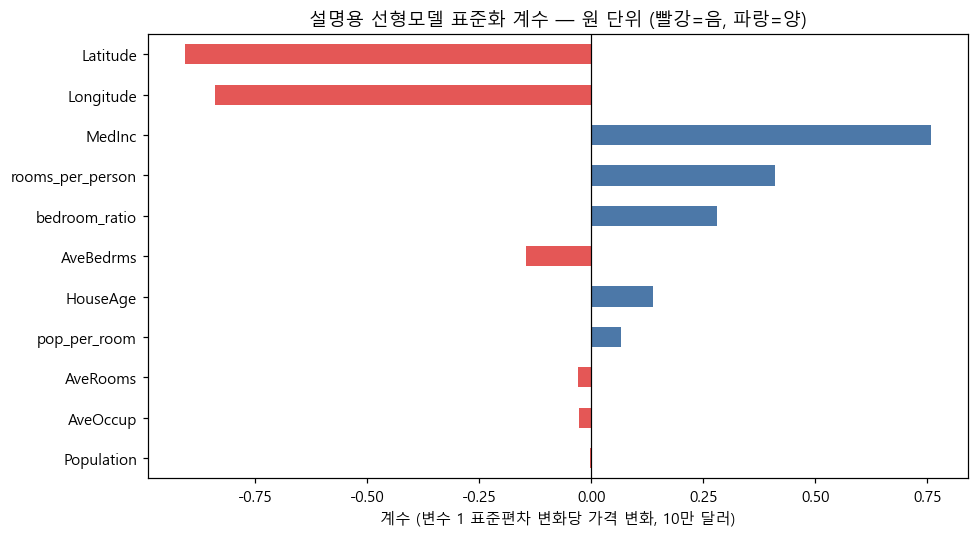

In [17]:
# 표준화된 계수 (스케일이 다른 변수를 공평하게 비교)
ridge_inner = explain_lin.named_steps["model"]
std_coef = pd.Series(ridge_inner.coef_, index=X_train_fe.columns).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#e45756" if c < 0 else "#4c78a8" for c in std_coef]
std_coef.plot.barh(ax=ax, color=colors)
ax.invert_yaxis()
ax.axvline(0, color="black", lw=0.8)
ax.set_title("설명용 선형모델 표준화 계수 — 원 단위 (빨강=음, 파랑=양)")
ax.set_xlabel("계수 (변수 1 표준편차 변화당 가격 변화, 10만 달러)")
plt.tight_layout(); plt.show()

**함정 1 — 표준화 없이는 계수 크기를 비교할 수 없다.**
`MedInc`(만 달러)와 `Latitude`(도)는 단위가 달라 원시 계수 크기로는 중요도를 비교할 수 없습니다. 위 그림은 **모든 변수를 표준화**한 뒤의 계수라 비교가 가능합니다.

**함정 2 — 공선성 아래에서는 부호가 뒤집힌다.**
`AveRooms`(방 수)와 `AveBedrms`(침실 수)는 강하게 상관됩니다. 두 변수를 같이 넣으면 한쪽 계수가 음수로 나오기도 합니다. "방이 많을수록 값이 내린다"는 비상식적 결론처럼 보이지만, 이는 "*침실 수를 고정한 채* 방 수만 늘리면"이라는 조건부 해석일 뿐입니다. 변수 단독의 효과와 혼동하면 안 됩니다.

**함정 3 — 계수는 인과가 아니다.**
계수는 *관측된 연관*이지 *개입했을 때의 효과*가 아닙니다. "방을 한 칸 늘리면 집값이 X 오른다"는 인과 주장은 회귀 계수만으로 할 수 없습니다(교란변수·역인과 가능성). 인과가 필요하면 실험(A/B)이나 준실험 설계가 따로 필요합니다.

> 💡 그래서 변수 영향력을 제대로 보려면 계수 하나만으로는 부족합니다. 다음 Part에서 계수에 기대지 않는 영향력 분석 도구들을 봅니다.


---
## Part 6. 변수 영향력 분석 — 변수를 고정하고 하나만 움직여 본다

사업팀의 "무엇이 가격을 움직이나"에 답하는 단계입니다. 계수에 의존하지 않고, 모델 종류와 상관없이 쓸 수 있는 네 가지 도구를 적용합니다. 핵심 아이디어는 한 문장입니다. **나머지를 그대로 둔 채 변수 하나만 건드려, 예측이 어떻게 반응하는지 본다.**

| 도구 | 답하는 질문 | 한 줄 직관 |
|---|---|---|
| **Permutation Importance** | 이 변수를 망가뜨리면 예측이 얼마나 나빠지나 | 변수 하나를 *셔플*해 정보를 지운 뒤 성능 하락폭 측정 |
| **PDP** (부분 의존도) | 이 변수만 바꾸면 예측이 평균적으로 어떻게 변하나 | 나머지를 *고정*하고 한 변수만 쓸어 본다 |
| **ICE** (개별 조건부 기대) | 그 변화가 모든 집에 똑같나, 집마다 다른가 | PDP를 개체별로 쪼갠 것 |
| **SHAP** | *이* 집의 예측은 왜 이 값이 됐나 | 예측을 변수별 기여로 정확히 분해 |


### 6-1. Permutation Importance — "이 변수가 없으면 얼마나 나빠지나"

한 변수의 값을 **무작위로 섞으면**(그 변수와 타깃의 관계를 끊으면) 예측 성능이 얼마나 떨어지는지 잽니다. 많이 떨어질수록 그 변수가 예측에 크게 기여한 것입니다.

> 💡 **impurity 기반 중요도(트리의 `feature_importances_`)보다 신뢰할 수 있습니다.** Permutation은 **테스트셋**에서 실제 예측 기여를 재므로, 학습셋 과적합이나 high-cardinality 편향에 덜 휘둘립니다.


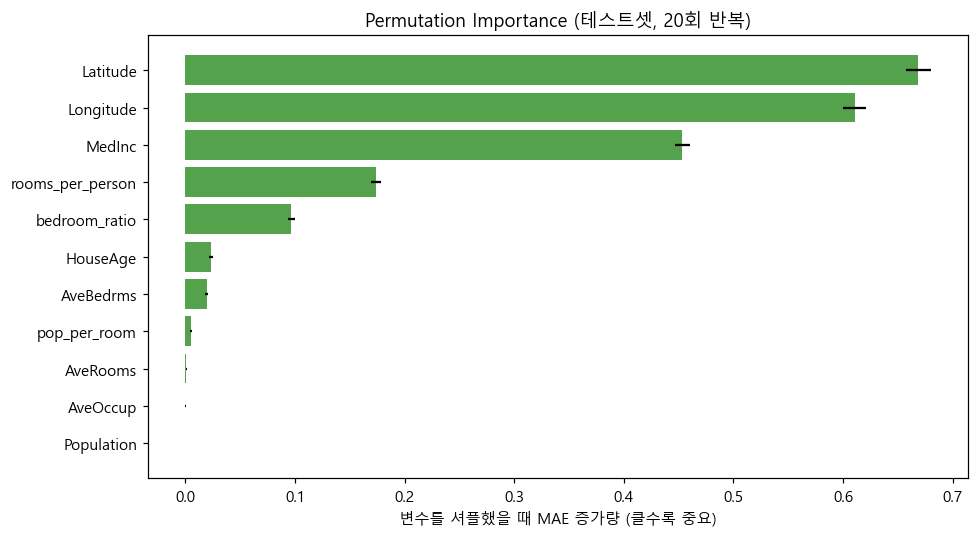

,변수,중요도(MAE 증가량),표준편차
6,Latitude,0.6688,0.0111
7,Longitude,0.6107,0.0104
0,MedInc,0.4535,0.0069
9,rooms_per_person,0.1739,0.0050
8,bedroom_ratio,0.0967,0.0031
1,HouseAge,0.0236,0.0021
3,AveBedrms,0.0195,0.0013
10,pop_per_room,0.0055,0.0009
2,AveRooms,0.0007,0.0004
5,AveOccup,0.0001,0.0005


In [18]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    explain_lin, X_test_fe, y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=20, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({
    "변수": X_test_fe.columns,
    "중요도(MAE 증가량)": perm.importances_mean,
    "표준편차": perm.importances_std,
}).sort_values("중요도(MAE 증가량)", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(perm_df["변수"], perm_df["중요도(MAE 증가량)"],
        xerr=perm_df["표준편차"], color="#54a24b")
ax.invert_yaxis()
ax.set_title("Permutation Importance (테스트셋, 20회 반복)")
ax.set_xlabel("변수를 셔플했을 때 MAE 증가량 (클수록 중요)")
plt.tight_layout(); plt.show()
perm_df.round(4)

> 🎯 **도입부 질문에 대한 답 — "소득인가, 위치인가?"** 결과는 분명합니다. **위치(Latitude·Longitude)가 소득(MedInc)보다 예측에 더 크게 기여**합니다(중요도 0.67·0.61 vs 0.45). 캘리포니아 집값은 "얼마를 버느냐"보다 "어디에 있느냐"가 더 좌우한다는 뜻이고, 이는 앞의 계수 그림에서 위치 계수가 가장 컸던 것과도 일치합니다.
>
> 단, *"방을 늘리면 값이 오르나?"* 에는 이 그림만으로 답하면 안 됩니다 — Part 5의 **함정 3(계수·중요도 ≠ 인과)** 때문입니다. 중요도가 높다고 해서 그 변수를 실제로 *바꿨을 때* 가격이 그만큼 변한다는 보장은 없습니다.

### 6-2. PDP — 변수 하나만 쓸어 본다

PDP(Partial Dependence Plot, 부분 의존도 그래프)는 나머지 변수를 데이터 그대로 둔 채, 관심 변수 하나만 최솟값에서 최댓값까지 쓸면서 예측이 평균적으로 어떻게 변하는지 그립니다. "변수를 고정하고 하나만 움직여 본다"는 아이디어를 그림으로 옮긴 것입니다.

조금 더 정확히는, 데이터의 모든 행에 대해 그 변수만 특정 값으로 바꿔 예측한 뒤 평균을 냅니다. 그 변수가 그 값일 때 예측이 평균적으로 어디쯤 가는지를 보여 줍니다.


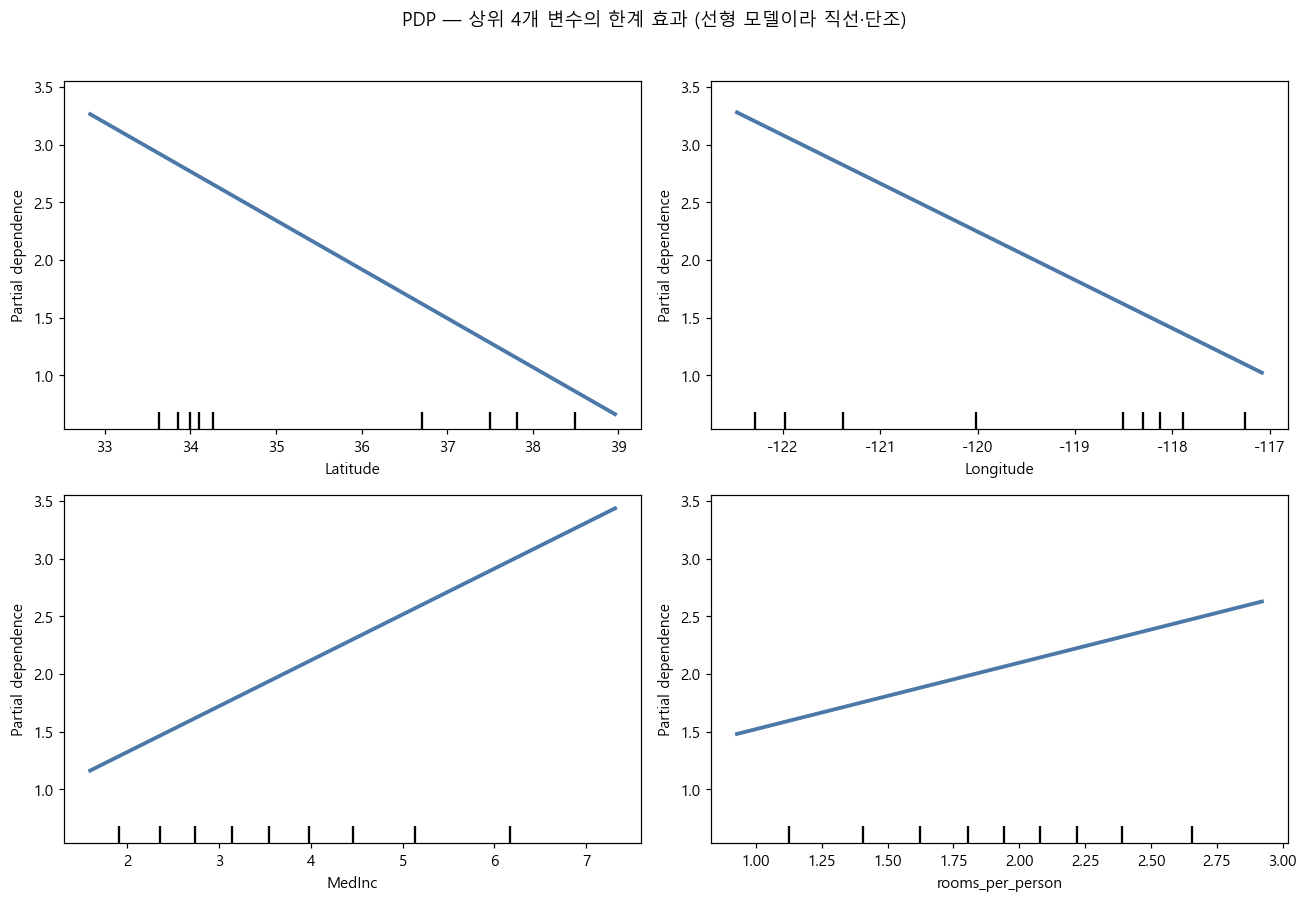

In [19]:
from sklearn.inspection import PartialDependenceDisplay

top4 = perm_df["변수"].head(4).tolist()
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    explain_lin, X_train_fe, features=top4, ax=ax.ravel(),
    line_kw={"color": "#4c78a8", "linewidth": 2.5})
fig.suptitle("PDP — 상위 4개 변수의 한계 효과 (선형 모델이라 직선·단조)", y=1.02)
plt.tight_layout(); plt.show()

선형 모델의 PDP는 당연히 **직선**입니다(모델 자체가 선형이니까). PDP의 진짜 위력은 **비선형 모델**에서 드러납니다 — Part 7에서 같은 그림을 *스플라인 회귀*로 다시 그리면, 소득이 일정 수준을 넘으면 효과가 꺾이는 식의 **곡선**이 보입니다. (모델을 트리로 바꾸지 않고도, 피처를 곡선 기저로 바꾸는 것만으로 비선형을 얻습니다.)

> ⚠️ **PDP 함정.** PDP는 "나머지 변수가 관심 변수와 독립"이라고 가정하고 평균을 냅니다. 변수끼리 강하게 상관되면(예: 위도·경도) PDP가 **현실에 없는 조합**(바다 한가운데 위치 등)까지 평균에 넣어 왜곡될 수 있습니다. 그래서 다음의 ICE·2D PDP로 보완합니다.

### 6-3. ICE — 평균에 가려진 개체별 차이

PDP는 **평균** 곡선이라 "어떤 집은 소득 효과가 크고, 어떤 집은 작다"는 차이를 숨깁니다. ICE는 **집 한 채 한 채**의 곡선을 그려, 효과가 균일한지 집단마다 다른지(상호작용의 신호)를 보여 줍니다.


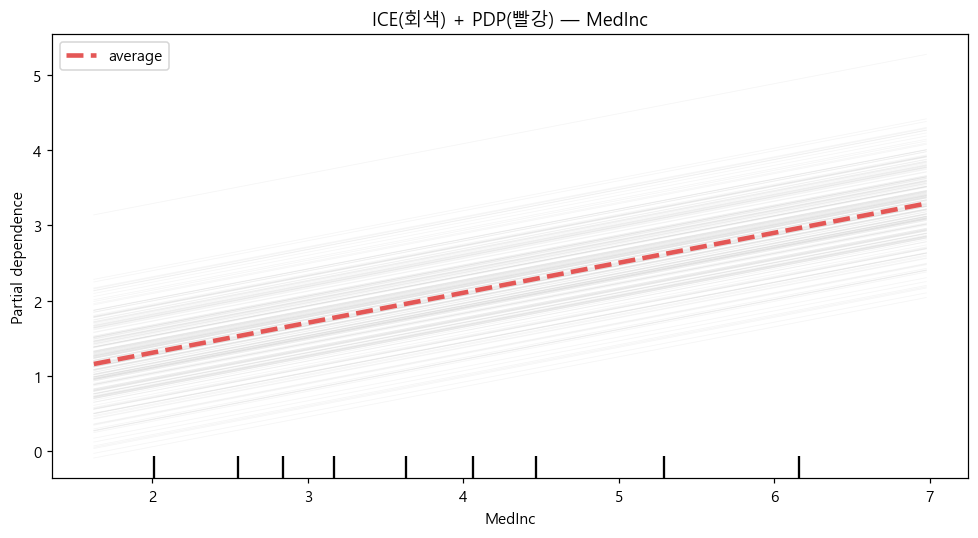

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
PartialDependenceDisplay.from_estimator(
    explain_lin, X_train_fe.sample(200, random_state=0), features=["MedInc"],
    kind="both", ax=ax,                    # both = ICE 선들 + PDP 평균선
    ice_lines_kw={"alpha": 0.15, "color": "#bbbbbb"},
    pd_line_kw={"color": "#e45756", "linewidth": 3})
ax.set_title("ICE(회색) + PDP(빨강) — MedInc")
plt.tight_layout(); plt.show()

### 6-4. SHAP — "이 한 채는 왜 이 값으로 예측됐나"

지금까지는 전체 데이터를 아우르는 전역(global) 영향력이었습니다. 실무에서는 개별 예측 하나를 설명해야 할 때도 많습니다. 예를 들면 *"이 매물이 평균보다 12만 달러 높게 평가된 이유는 소득 수준 +7만, 위치 +6만, 방 수 −1만 때문입니다"* 처럼요. SHAP은 한 건의 예측을 **변수별 기여액의 합**으로 정확히 분해합니다. 게임이론의 Shapley 값에 기반해, 각 변수가 기준값 대비 예측을 얼마나 끌어올리거나 내렸는지를 더하면 정확히 그 예측값이 됩니다.

> 📖 **개념 — 기준값(base value).** 아무 변수 정보도 모를 때 내놓을 예측, 곧 **전체 데이터의 평균 예측값**입니다. SHAP은 이 기준값에서 출발해 변수별 기여(+/−)를 차곡차곡 더해 *이* 매물의 최종 예측에 도달합니다. 그래서 아래 워터폴 그림은 맨 아래 기준값 → 변수 기여 → 맨 위 최종 예측 순으로 읽습니다.

> 💡 `shap`이 설치돼 있지 않으면 맨 위 셀에서 `!pip install -q shap` 을 실행한 뒤 다시 돌리세요. 아래 코드는 미설치 상태에서도 노트북이 멈추지 않도록 감싸 두었습니다.

Background dataset has 4128 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4128 when initializing the masker.


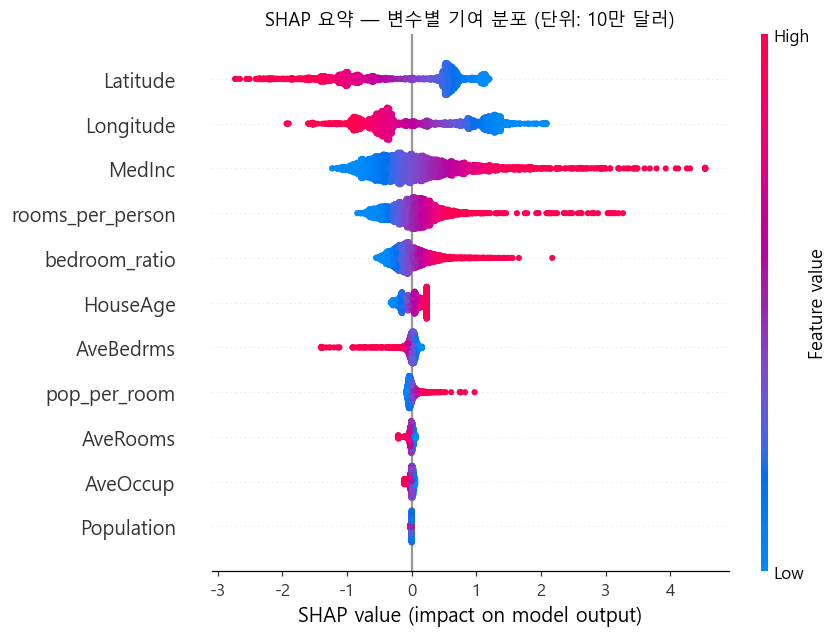

In [21]:
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("shap 미설치 — '!pip install -q shap' 후 이 셀부터 다시 실행하세요. (건너뜀)")

if HAS_SHAP:
    # 설명용 선형 모델에 SHAP — 원 단위(10만 달러)라 기여액을 바로 읽는다
    scaler = explain_lin.named_steps["scaler"]
    X_test_scaled = scaler.transform(X_test_fe)
    explainer = shap.LinearExplainer(explain_lin.named_steps["model"], X_test_scaled)
    shap_values = explainer(X_test_scaled)
    shap_values.feature_names = list(X_test_fe.columns)

    shap.plots.beeswarm(shap_values, max_display=12, show=False)
    plt.title("SHAP 요약 — 변수별 기여 분포 (단위: 10만 달러)")
    plt.tight_layout(); plt.show()

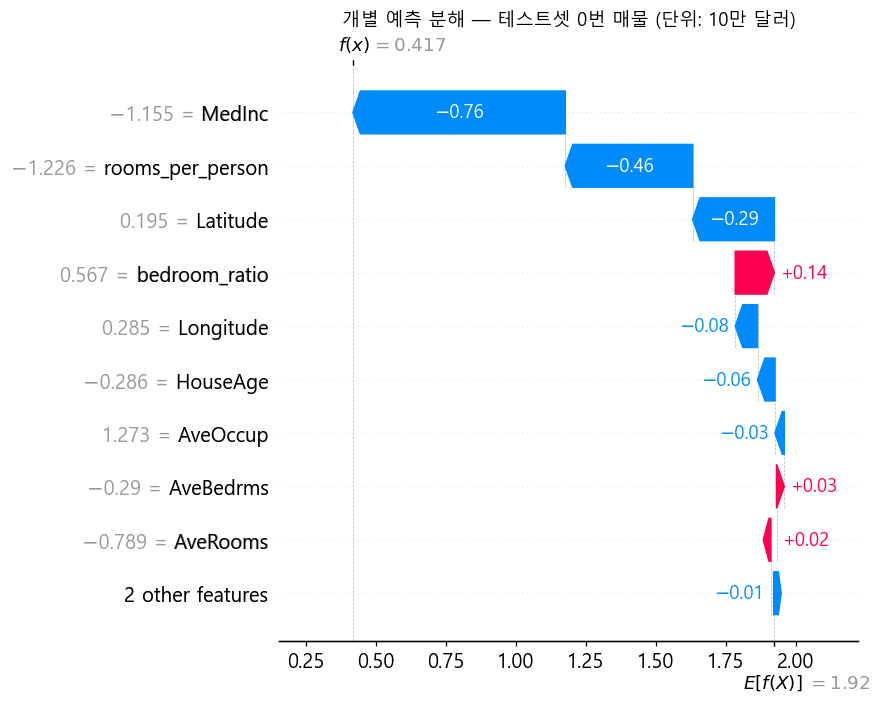

기준값 + 변수별 기여 합 = 예측 $42k  (실제 $48k)


In [22]:
if HAS_SHAP:
    # 개별 예측 1건 분해 — 고객 설명용 (기여액 단위: 10만 달러)
    idx = 0
    shap.plots.waterfall(shap_values[idx], max_display=10, show=False)
    plt.title(f"개별 예측 분해 — 테스트셋 {idx}번 매물 (단위: 10만 달러)")
    plt.tight_layout(); plt.show()
    pred1 = explain_lin.predict(X_test_fe.iloc[[idx]])[0]
    print(f"기준값 + 변수별 기여 합 = 예측 ${pred1*100:.0f}k  (실제 ${y_test.iloc[idx]*100:.0f}k)")

---
## Part 7. 비선형으로 — 회귀를 벗어나지 않고 곡선 잡기

선형 모델은 "변수가 1 늘면 가격은 *항상 같은 양만큼* 오른다"는 **직선 효과**를 가정합니다. 하지만 집값은 그렇지 않죠 — 소득이 아주 높은 구간에선 상승이 둔해지는(포화) 식의 곡선입니다. 그렇다고 곧장 다른 종류의 모델(트리 등)로 갈아탈 필요는 없습니다. **모델은 그대로 선형 회귀로 두고, 피처를 곡선으로 바꾸면** 됩니다.

> 📖 **개념 — 스플라인(spline) 기저 변환.** 변수 하나(예: 소득)를 여러 개의 매끄러운 곡선 조각(기저 함수)으로 펼칩니다. 그러면 회귀는 이 곡선들에 각각 계수를 붙여 더하므로, 결과적으로 **변수와 가격의 관계가 휘어진 곡선**이 됩니다. 핵심은 — 모델은 여전히 *계수에 대해 선형*인 보통의 회귀라, 앞서 쓴 `Pipeline`·정규화·해석 도구가 **그대로** 통한다는 점입니다. `PolynomialFeatures`(다항식)도 같은 발상이지만, 스플라인이 구간을 나눠 다뤄 과도한 출렁임이 적습니다.

> 💡 스플라인은 변수가 늘어난 만큼 계수도 많아지므로, **정규화(Ridge)** 와 짝지어 안정화합니다 — Part 4에서 만든 도구를 다시 쓰는 셈입니다. 이렇게 비선형 회귀로 성능을 끌어올린 뒤, 해석 도구(Permutation·PDP)를 그대로 다시 적용해 "도구가 모델과 무관하게 작동"함을 확인합니다.

In [23]:
from sklearn.preprocessing import SplineTransformer

# 비선형으로 가는 길 — 모델을 바꾸지 않고 '피처를 곡선'으로 만든다.
# 각 변수를 스플라인 기저로 펼치면 같은 선형 회귀가 변수별 곡선을 학습한다(계수에 대해선 여전히 선형).
spline_reg = TransformedTargetRegressor(
    regressor=Pipeline([
        ("spline", SplineTransformer(n_knots=5, degree=3)),   # 변수마다 매끄러운 곡선 기저
        ("scaler", StandardScaler()),
        ("model",  RidgeCV(alphas=np.logspace(-3, 3, 40))),    # 늘어난 기저를 정규화로 안정화
    ]),
    func=np.log1p, inverse_func=np.expm1)

s = cross_val_score(spline_reg, X_train_fe, y_train,
                    scoring="neg_mean_absolute_error", cv=cv)
print(f"선형+FE+log  CV MAE: {-neg_mae_log.mean():.3f}  (직선 효과 가정)")
print(f"스플라인 회귀 CV MAE: {-s.mean():.3f} ± {s.std():.3f}  (곡선 허용)")

선형+FE+log  CV MAE: 0.475  (직선 효과 가정)
스플라인 회귀 CV MAE: 0.415 ± 0.009  (곡선 허용)


In [24]:
spline_reg.fit(X_train_fe, y_train)
pred_spline = spline_reg.predict(X_test_fe)
results.append(평가(y_test, pred_spline, "스플라인+Ridge"))

# 지금까지의 모든 모델 비교
board = pd.DataFrame(results).set_index("이름").round(3)
board["MAE 개선율(vs 베이스라인)"] = (
    (board.loc["베이스라인(평균)", "MAE"] - board["MAE"]) /
    board.loc["베이스라인(평균)", "MAE"] * 100).round(1)
board

[스플라인+Ridge        ] MAE=0.421 (±$42.1k)  RMSE=0.610  MAPE=23.4%


,MAE,RMSE,MAPE,MAE 개선율(vs 베이스라인)
이름,,,,
베이스라인(평균),0.906,1.145,62.886,0.0
선형회귀(기본),0.533,0.746,31.952,41.2
선형+FE+log,0.478,0.745,26.648,47.2
Ridge+FE+log,0.478,0.745,26.652,47.2
스플라인+Ridge,0.421,0.610,23.426,53.5


### 같은 PDP를 비선형(스플라인) 모델로 다시 — 이제 곡선이 보인다

선형 모델에서 직선이던 PDP가, 스플라인 회귀에서는 **휘는 곡선**으로 나타납니다. 소득이 일정 수준을 넘으면 가격 상승이 둔화되거나(포화), 특정 구간에서 기울기가 변하는 **현실적인 비선형**이 드러납니다. 모델 종류를 바꾼 게 아니라 *피처를 곡선 기저로 바꿨을 뿐*인데 PDP 도구는 똑같이 작동합니다.

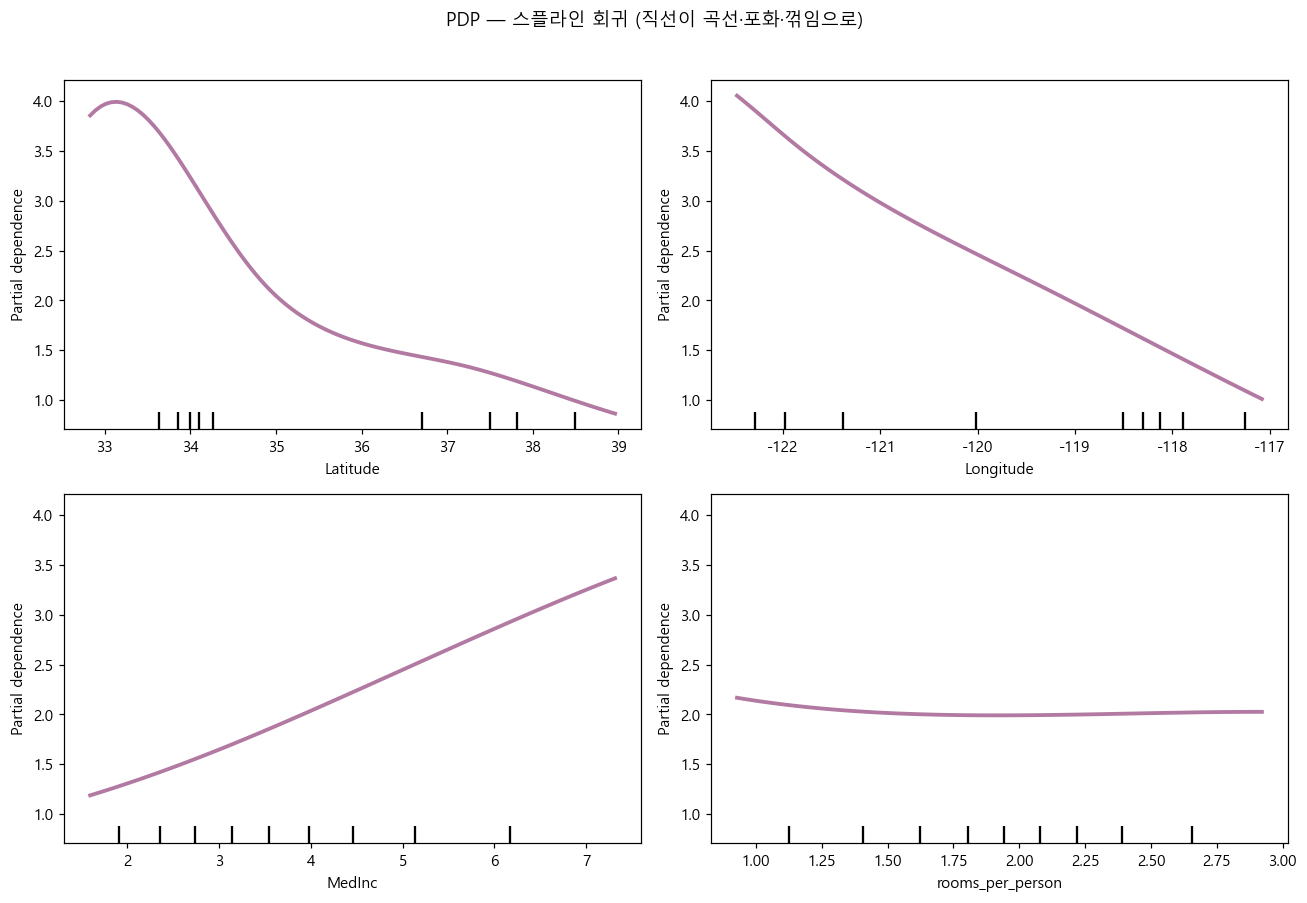

In [27]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    spline_reg, X_train_fe, features=top4, ax=ax.ravel(),
    line_kw={"color": "#b279a2", "linewidth": 2.5})
fig.suptitle("PDP — 스플라인 회귀 (직선이 곡선·포화·꺾임으로)", y=1.02)
plt.tight_layout(); plt.show()

#### 2D PDP — 위치 효과, 그리고 가법 모델의 한계

위도와 경도를 함께 쓸어 2D로 봅니다. 그런데 스플라인 회귀는 변수별 곡선을 *더하는* **가법(additive) 모델**이라, 아래 그림은 위도 효과와 경도 효과를 단순히 합친 매끈한 면이 됩니다. 해안선·대도시(LA·SF)를 따라 솟는 진짜 "가격 지형"은 **위도와 경도의 상호작용**인데, 가법 모델은 이를 자동으로 잡지 못합니다.

> 💡 상호작용을 잡으려면 (1) 위경도 교차항을 손으로 넣거나 (2) 상호작용을 *자동으로* 학습하는 트리 기반 모델이 필요합니다 — 후자는 이 시리즈의 **결정트리(03)·랜덤포레스트(04)** 편에서 다룹니다. 여기서 얻을 교훈은, 같은 2D PDP 도구로 **"내 모델이 상호작용을 보고 있는가"를 진단**할 수 있다는 점입니다.

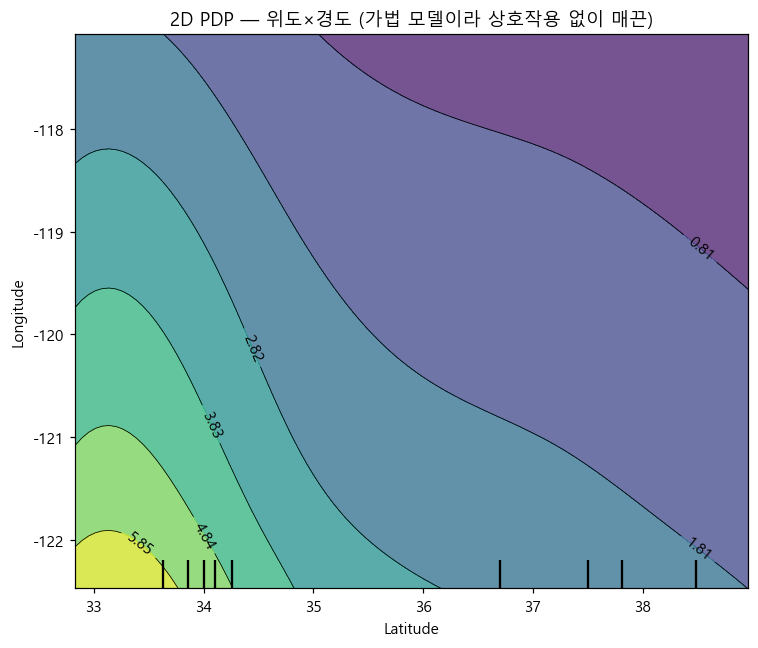

In [28]:
fig, ax = plt.subplots(figsize=(7, 6))
PartialDependenceDisplay.from_estimator(
    spline_reg, X_train_fe, features=[("Latitude", "Longitude")], ax=ax)
ax.set_title("2D PDP — 위도×경도 (가법 모델이라 상호작용 없이 매끈)")
plt.tight_layout(); plt.show()

#### 단조 제약은? — 회귀 family의 한계와 다음 단계

Part 4.5에서 본 **단조 제약**("소득↑ ⇒ 예측 가격↑을 보장")은 트리 모델의 `monotonic_cst` 로 가장 깔끔하게 걸립니다. 스플라인 회귀에서도 단조 스플라인·등위회귀(isotonic)로 흉내 낼 수 있지만 손이 많이 가고, 무엇보다 방금 본 **상호작용 자동 학습**은 트리 계열의 영역입니다.

> 💡 그래서 이 시리즈는 트리 기반 모델과 그 제약·해석을 **결정트리(03)·랜덤포레스트(04)** 편에서 본격적으로 다룹니다. 지금 챙길 핵심은 — 방금 쓴 해석 도구(Permutation·PDP)가 **선형이든 스플라인이든 트리든 모델과 무관하게 그대로 작동**한다는 점입니다. 아래에서 스플라인 모델로 Permutation을 다시 돌려 확인합니다.

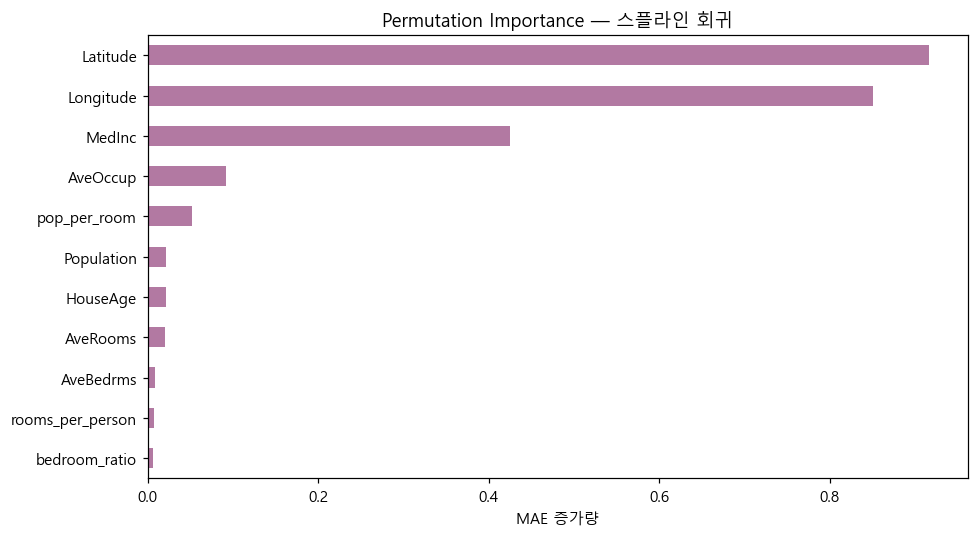

In [29]:
# 비선형(스플라인) 모델의 Permutation Importance — 선형과 순위가 달라질 수 있다
perm_sp = permutation_importance(
    spline_reg, X_test_fe, y_test, scoring="neg_mean_absolute_error",
    n_repeats=15, random_state=42, n_jobs=-1)
imp = pd.Series(perm_sp.importances_mean, index=X_test_fe.columns).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
imp.plot.barh(ax=ax, color="#b279a2")
ax.set_title("Permutation Importance — 스플라인 회귀")
ax.set_xlabel("MAE 증가량")
plt.tight_layout(); plt.show()

---
## Part 8. 예측을 신뢰할 수 있나 — 점 예측에 ±범위 붙이기

"이 집은 32만 달러"라는 점 예측 하나만 보고하면, 그 추정이 ±2만 달러쯤인지 ±15만 달러쯤인지 알 수 없습니다. 실무 AVM은 **예측 구간**을 함께 냅니다. 구간이 넓은(불확실한) 매물은 사람 감정사에게 넘기는 식으로, 리스크 관리에 바로 쓰입니다. 여기서는 Part 7까지 다룬 회귀 family 안의 도구인 **선형 분위 회귀(`QuantileRegressor`)** 를 씁니다.

> 📖 **개념 — 분위수(quantile)와 분위 회귀(quantile regression).** 분위수는 "데이터를 크기순으로 줄 세웠을 때 아래에서 몇 %지점의 값"입니다 — 50% 분위수가 곧 중앙값입니다. 보통 회귀는 *평균*을 예측하지만, 분위 회귀는 손실 함수를 바꿔(과소·과대 예측에 다른 벌점을 줘서) 원하는 *분위수*를 직접 예측합니다. 5%·50%·95% 세 모델을 따로 학습하면, **5% 예측 ~ 95% 예측 사이가 90% 예측 구간**이 됩니다 — 진짜 값이 그 안에 들어올 거라 90% 자신하는 범위라는 뜻입니다.

> 📖 **개념 — 커버리지(coverage).** 구간이 정직한지 검증하는 지표입니다. 테스트셋에서 *실제값이 90% 구간 안에 실제로 들어온 비율*을 세어, 90%에 가까우면 잘 보정된 구간입니다. 아래 출력의 coverage가 목표 90%보다 낮으면 구간이 **지나치게 좁다**(과신)는 뜻이고, 높으면 너무 넓다는 뜻입니다.

In [30]:
from sklearn.linear_model import QuantileRegressor

# 선형 분위 회귀 — 하·중·상 세 모델로 90% 구간. (LP 최적화라 fit 이 다소 느릴 수 있음)
q_models = {}
for q in [0.05, 0.5, 0.95]:
    q_models[q] = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  QuantileRegressor(quantile=q, alpha=0.001, solver="highs")),
    ]).fit(X_train_fe, y_train)

lo  = q_models[0.05].predict(X_test_fe)
mid = q_models[0.5].predict(X_test_fe)
hi  = q_models[0.95].predict(X_test_fe)

# 실제 타깃이 90% 구간 안에 들어온 비율 (coverage) — 0.90 에 가까워야 정직한 구간
coverage = ((y_test.values >= lo) & (y_test.values <= hi)).mean()
avg_width = (hi - lo).mean()
print(f"90% 예측구간 coverage: {coverage:.1%}  (목표 90%)")
print(f"평균 구간 폭: ±${avg_width/2*100:.1f}k")

90% 예측구간 coverage: 90.3%  (목표 90%)
평균 구간 폭: ±$97.6k


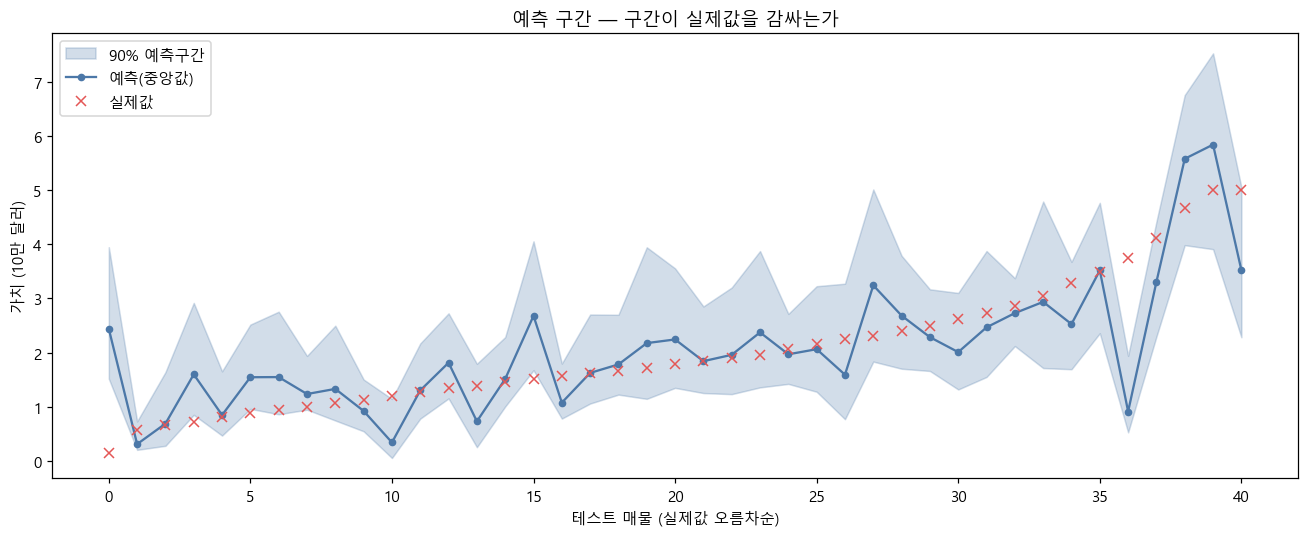

In [31]:
# 테스트셋 40채를 실제값 순으로 정렬해 예측·구간을 시각화
order = np.argsort(y_test.values)[::len(y_test)//40]
xs = np.arange(len(order))
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(xs, lo[order], hi[order], alpha=0.25, color="#4c78a8", label="90% 예측구간")
ax.plot(xs, mid[order], "o-", color="#4c78a8", ms=4, label="예측(중앙값)")
ax.plot(xs, y_test.values[order], "x", color="#e45756", ms=7, label="실제값")
ax.set_title("예측 구간 — 구간이 실제값을 감싸는가")
ax.set_xlabel("테스트 매물 (실제값 오름차순)"); ax.set_ylabel("가치 (10만 달러)")
ax.legend(); plt.tight_layout(); plt.show()

> ⚠️ 분위 회귀 구간은 보정이 완벽하진 않습니다(coverage가 정확히 90%가 아닐 수 있음). 보장된 구간이 필요하면 **conformal prediction**(예: `MAPIE` 라이브러리)으로 calibration set에서 구간을 사후 보정합니다 — 분포 가정 없이 목표 coverage를 보장하는 현장 표준 도구입니다.


---
## Part 9. 에러 분석 — "어디서 틀리는가"가 다음 개선의 지도

평균 성능 한 줄로 끝내지 않습니다. 어떤 구간, 어떤 매물에서 크게 틀리는지 분해하면, 다음에 무엇을 고칠지(피처 추가, 세그먼트별 모델, 데이터 보강)가 보입니다. 그 출발점이 잔차입니다.

> 📖 **개념 — 잔차(residual)와 이분산성(heteroscedasticity).** 잔차 = `실제값 − 예측값`, 모델이 놓친 부분입니다. 부호도 정보인데, 이 노트북에선 **양수면 과소예측**(실제가 예측보다 비쌌다), **음수면 과대예측**입니다.
>
> 진단법은 잔차를 *예측값에 대해* 흩뿌려 보는 것입니다(아래 왼쪽 그림). **아무 패턴 없이 0 주변에 고르게** 퍼지면 건강한 신호입니다. 경계할 두 가지는 — ① 어떤 구간에서 잔차 평균이 0에서 벗어나 한쪽으로 쏠리면, 모델이 그 구간의 구조를 놓친 것입니다(이 데이터의 상한 50만 구간이 그 예). ② 예측값이 커질수록 잔차 폭이 부채꼴로 넓어지면 **이분산성**입니다 — 오차 크기가 일정하지 않다는 뜻이라, 모든 예측에 똑같은 ±폭을 붙이는 단순 신뢰구간이 부정확해집니다. (그래서 Part 8의 분위 회귀처럼 구간 폭을 데이터가 스스로 정하게 하는 방법이 필요했던 것입니다.)

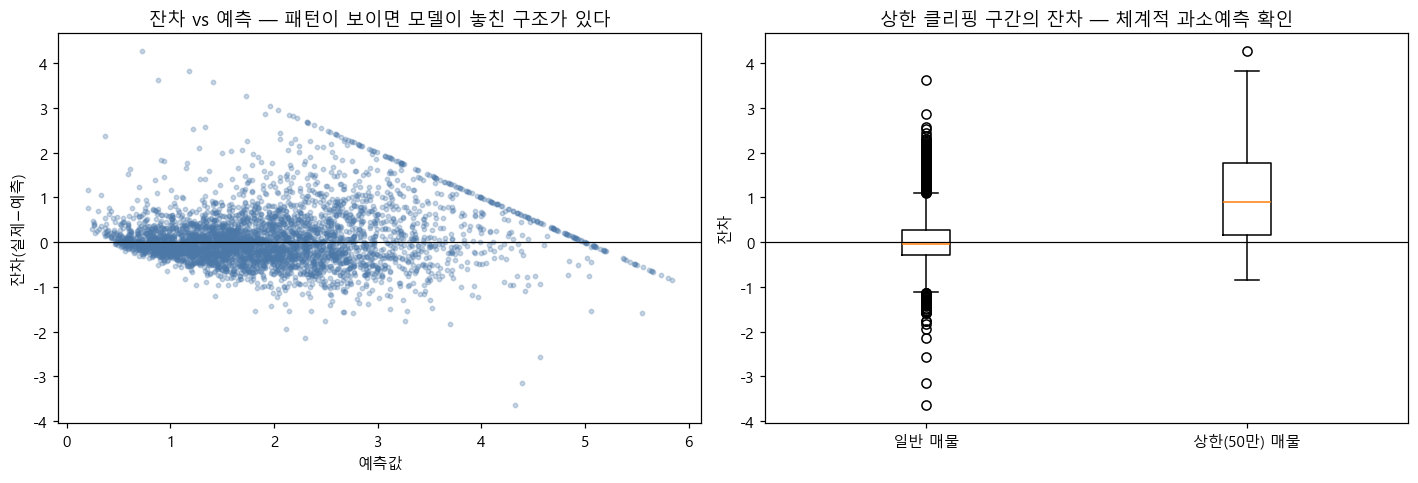

일반 매물 평균오차 : +0.020
상한 매물 평균오차 : +0.993  ← Part 0 에서 예고한 함정


In [32]:
resid = y_test.values - pred_spline         # 양수=과소예측, 음수=과대예측
err_df = X_test_fe.copy()
err_df["실제"] = y_test.values
err_df["예측"] = pred_spline
err_df["오차"] = resid
err_df["절대오차"] = np.abs(resid)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(pred_spline, resid, s=8, alpha=0.3, color="#4c78a8")
ax[0].axhline(0, color="black", lw=0.8)
ax[0].set_title("잔차 vs 예측 — 패턴이 보이면 모델이 놓친 구조가 있다")
ax[0].set_xlabel("예측값"); ax[0].set_ylabel("잔차(실제−예측)")

# Part 0 의 상한 클리핑 구간에서 오차가 어떤가 — 예고했던 함정으로 복귀
is_capped = np.isclose(y_test.values, df["MedHouseVal"].max())
ax[1].boxplot([resid[~is_capped], resid[is_capped]], labels=["일반 매물", "상한(50만) 매물"])
ax[1].axhline(0, color="black", lw=0.8)
ax[1].set_title("상한 클리핑 구간의 잔차 — 체계적 과소예측 확인")
ax[1].set_ylabel("잔차")
plt.tight_layout(); plt.show()

print(f"일반 매물 평균오차 : {resid[~is_capped].mean():+.3f}")
print(f"상한 매물 평균오차 : {resid[is_capped].mean():+.3f}  ← Part 0 에서 예고한 함정")

In [33]:
# 가장 크게 틀린 매물 Top 5 — 개별 진단 (SHAP 으로 원인 추적하면 좋음)
print("절대오차 상위 5개 매물:")
err_df.sort_values("절대오차", ascending=False).head(5)[
    ["MedInc", "AveRooms", "AveOccup", "Latitude", "Longitude", "실제", "예측", "오차"]].round(2)

절대오차 상위 5개 매물:


,MedInc,AveRooms,AveOccup,Latitude,Longitude,실제,예측,오차
6688,0.50,7.68,4.58,34.15,-118.08,5.00,0.72,4.28
10574,1.97,4.80,2.84,33.72,-117.70,5.00,1.18,3.82
4548,7.58,3.14,6.09,34.02,-118.21,0.68,4.33,-3.65
19542,1.77,5.00,2.44,37.63,-120.92,4.50,0.88,3.62
459,1.17,2.44,5.40,37.87,-122.25,5.00,1.41,3.59


### 📋 모델 카드 — 마무리 보고

| 항목 | 내용 |
|---|---|
| **목적** | 캘리포니아 구역 단위 주택 가치 자동 평가(AVM) + 가격 요인 설명 |
| **데이터** | California Housing (1990 인구조사, 20,640 구역). ⚠️ 타깃 50만 달러 상한 클리핑 ~5% |
| **최종 모델** | 스플라인 회귀(SplineTransformer + RidgeCV, log 타깃) — 회귀 family 안에서 비선형 확보. 설명은 원 단위 선형(RidgeCV) 보조 |
| **성능** | 베이스라인 대비 MAE 약 53% 개선 (위 비교표 참조). 선형 분위 회귀로 90% 예측구간 동시 제공 |
| **핵심 변수** | 위치(위·경도) · 중위소득(MedInc) · 쾌적도(rooms_per_person) — Permutation·PDP·SHAP 대체로 일치 |
| **한계** | (1) 50만 초과 매물 체계적 과소예측 (2) 가법 모델이라 위치 상호작용 미포착(→ 트리 계열) (3) 1990년 데이터로 현재 시세 직접 적용 불가 (4) 계수·중요도는 연관이지 인과 아님 |
| **다음 작업** | 위경도 상호작용/트리 모델(03·04) · 상한 구간 별도 분류 · conformal 구간 보정 · 시점/거시변수 추가 |

---

### 🎓 이 노트북에서 가져갈 실무 원칙

1. **베이스라인 먼저.** 가장 단순한 모델을 못 이기면 그 모델은 쓸 이유가 없다.
2. **전처리는 파이프라인 안에서.** 데이터 누수는 조용히 점수를 부풀리고, 배포하면 그만큼 무너진다.
3. **피처와 타깃 변환**이 모델을 바꾸는 것보다 점수를 더 올릴 때가 많다 — 비선형조차 *피처를 곡선으로 바꾸는 것*(스플라인)으로 회귀 안에서 얻었다.
4. **계수 ≠ 중요도 ≠ 인과.** 표준화, 공선성, 인과를 구분해서 읽어라.
5. **가중치는 직접 조절할 수 있다.** 관측치 가중으로 무엇을 더 믿을지, 계수 제약으로 부호·단조 방향을 정해 도메인 지식을 모델에 넣어라. 단, 제약이 도메인과 맞을 때만.
6. **변수 영향력은 변수를 고정하고 본다.** Permutation은 기여도, PDP는 한계효과, ICE는 개체별 차이, SHAP은 개별 예측 설명. 이 도구들은 모델 종류와 무관하게 쓰인다.
7. **점 예측에 구간을 붙여라.** 불확실성을 숨기지 않는 것이 실무 신뢰의 핵심이다.
8. **에러 분석이 다음 개선의 지도다.** 평균 성능 한 줄로 끝내지 마라.

다음 노트북에서는 분류 문제로 넘어갑니다. 고객 이탈 예측을 소재로 불균형 데이터, 확률 보정, 비용 기반 임계값 결정을 다룹니다. 비선형의 또 다른 축인 **트리 기반 모델(결정트리·랜덤포레스트)** 도 그 흐름에서 본격적으로 만납니다.